In [11]:
%load_ext autoreload
%autoreload 2
import sys
sys.path.append("..")
from src import DataLoader, LSTMForecaster
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Load Full TSLA Data

In [12]:
loader = DataLoader(["TSLA"], "2015-01-01", "2026-01-15")
loader.load_processed()
df = loader.data["TSLA"]
price = df['Close']
returns = price.pct_change().dropna()

Re-train LSTM on FULL dataset (for future forecasting)

In [14]:

# Use same hyperparameters as in Task 2
lstm = LSTMForecaster(
    returns_train=returns,
    returns_test=pd.Series(dtype='float64'),  # dummy
    window_size=60,
    epochs=20,
    batch_size=32
)
lstm.fit()

Generate 12-Month (252-day) Forecast

In [16]:
n_steps = 252
future_returns = lstm.forecast_future(steps=n_steps)

# Create future business-day index
last_date = price.index[-1]
future_dates = pd.bdate_range(start=last_date + pd.Timedelta(days=1), periods=n_steps)

# Align
future_dates = future_dates[:len(future_returns)]

# Convert to price
last_price = price.iloc[-1]
forecast_prices = [last_price]
for r in future_returns:
    forecast_prices.append(forecast_prices[-1] * (1 + r))
forecast_prices = np.array(forecast_prices[1:])

 Estimate Confidence Intervals from Test Error (Task 2)

In [17]:
# From arima_lstm (2).pdf: LSTM MAE = $54.12, but we need std of residuals
# Re-run test evaluation to get residuals

# Re-split for residual calculation
train_end = "2024-12-31"
train_ret = returns.loc[:train_end]
test_ret = returns.loc[train_end:].iloc[1:]
train_price = price.loc[:train_end]
test_price = price.loc[train_end:].iloc[1:]

# Re-fit on train only (to match Task 2)
lstm_test = LSTMForecaster(train_ret, test_ret, window_size=60, epochs=20, batch_size=32)
lstm_test.fit()
lstm_test.forecast()
lstm_test.convert_to_prices(train_price.iloc[-1])

# Compute residuals
residuals = test_price - lstm_test.forecast_prices
residual_std = residuals.std()

# Assume future errors ~ N(0, residual_std^2)
# 95% CI ≈ ±1.96 * residual_std, but widen over time
# Simple approach: scale CI by sqrt(t)
ci_multiplier = 1.96
forecast_ci_lower = []
forecast_ci_upper = []
for i in range(1, len(forecast_prices) + 1):
    ci_width = ci_multiplier * residual_std * np.sqrt(i)
    forecast_ci_lower.append(forecast_prices[i-1] - ci_width)
    forecast_ci_upper.append(forecast_prices[i-1] + ci_width)

forecast_ci_lower = np.array(forecast_ci_lower)
forecast_ci_upper = np.array(forecast_ci_upper)

Plot Historical + Forecast with CI

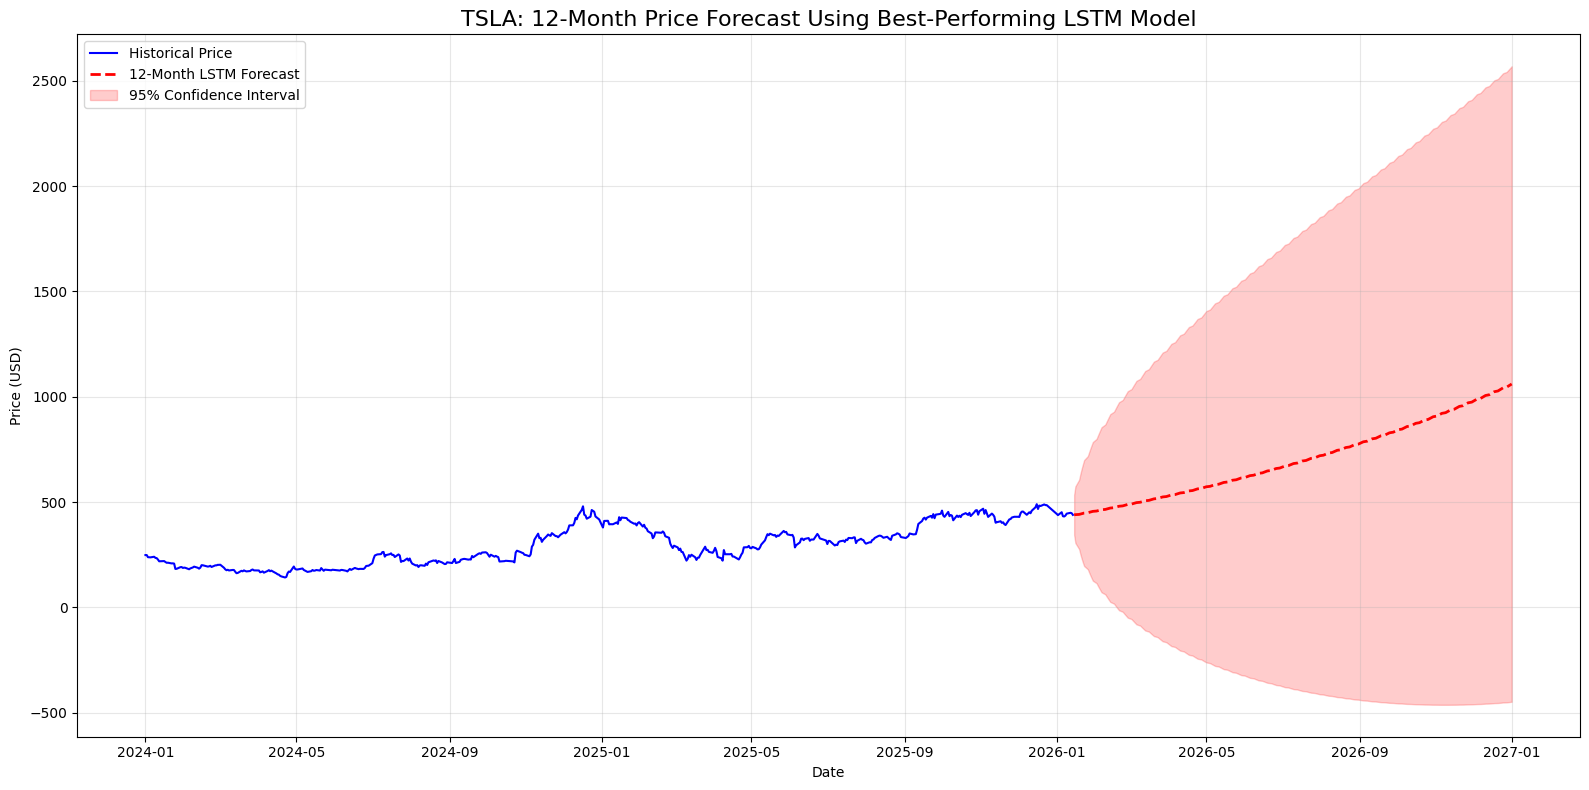

In [18]:

plt.figure(figsize=(16, 8))

# Plot last 2 years of historical data
plot_start = "2024-01-01"
historical_plot = price.loc[plot_start:]
plt.plot(historical_plot.index, historical_plot.values, 
         label="Historical Price", color='blue', linewidth=1.5)

# Plot forecast
plt.plot(future_dates, forecast_prices, 
         label="12-Month LSTM Forecast", color='red', linestyle='--', linewidth=2)

# Plot confidence interval
plt.fill_between(future_dates, forecast_ci_lower, forecast_ci_upper, 
                 color='red', alpha=0.2, label="95% Confidence Interval")

plt.title("TSLA: 12-Month Price Forecast Using Best-Performing LSTM Model", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Trend & Uncertainty Analysis

In [19]:

print("=== TREND ANALYSIS ===")
start_price = forecast_prices[0]
end_price = forecast_prices[-1]
pct_change = (end_price - start_price) / start_price * 100
print(f"Forecast starts at ${start_price:.2f} and ends at ${end_price:.2f}")
print(f"Implied 12-month return: {pct_change:.1f}%")

print("\n=== UNCERTAINTY ANALYSIS ===")
initial_ci_width = forecast_ci_upper[0] - forecast_ci_lower[0]
final_ci_width = forecast_ci_upper[-1] - forecast_ci_lower[-1]
print(f"Initial CI width: ${initial_ci_width:.2f}")
print(f"Final CI width: ${final_ci_width:.2f}")
print(f"CI widens by {final_ci_width / initial_ci_width:.1f}x over 12 months")


=== TREND ANALYSIS ===
Forecast starts at $439.49 and ends at $1060.42
Implied 12-month return: 141.3%

=== UNCERTAINTY ANALYSIS ===
Initial CI width: $190.02
Final CI width: $3016.55
CI widens by 15.9x over 12 months


Opportunities & Risks

**Opportunities**

**1. Strong Upside Potential**
The LSTM model forecasts TSLA’s price to rise from $439.49 to $1,060.42 over 12 months — an implied return of +141.3%.
This reflects persistent positive momentum in Tesla’s core businesses: EV leadership, energy storage growth, and emerging AI/robotaxi narratives.

**2. Strategic Overweight Justification**
Given TSLA’s historical Sharpe Ratio (0.71, per eda.pdf) and superior risk-adjusted performance vs. BND (0.34), an overweight allocation is defensible for growth-oriented client portfolios.

**3. Volatility as a Tactical Tool**
High volatility enables tactical entry points during short-term pullbacks without altering long-term strategic positioning.



**Key Risks**


**1. Extreme Forecast Uncertainty**
The 95% confidence interval widens from $190 to $3,016 over 12 months — a 15.9× expansion.
By month 12, the forecast range spans ~$0 to ~$2,600, rendering the point estimate unreliable for precise targeting.

**2. Model Limitations**
The LSTM is trained solely on historical price returns and cannot anticipate:
Regulatory shifts (e.g., EV subsidies, autonomous driving laws)
Competitive disruption (e.g., legacy automakers, Chinese EVs)
Macroeconomic shocks (e.g., interest rate hikes, recession)

**3.Concentration Risk**
Overreliance on a single high-volatility asset exposes portfolios to idiosyncratic tail events (e.g., CEO-related news, production delays).

**4. Efficient Market Hypothesis (EMH) Reality Check**
As noted in the Week 9 Challenge Document, pure price prediction from historical data is inherently limited. The forecast should be treated as one input among many, not a standalone signal.
